# **YOLOV1 plots explanation**

In [3]:
from PIL import Image
from pathlib import Path

import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

path = Path.cwd()
while not (path / "computer_vision").exists():
    path = path.parent

sys.path.append(str(path))

datasets_path = "/home/otokonokage/Documents/github/dataset/computer_vision/"

In [4]:
from computer_vision.datasets import vocdetection

dataset_path, annotations, weights, num_classes, categories, dataset_name, dataset_box_format, mode, dataset_normalized = vocdetection(datasets_path, "train", year="2012")
reversed_categories = dict([(id, label) for label, id in categories.items()])
print(dataset_box_format)

xyxy


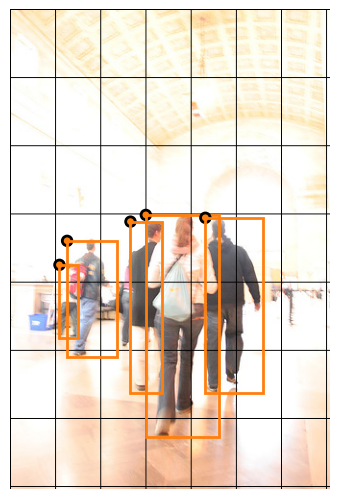

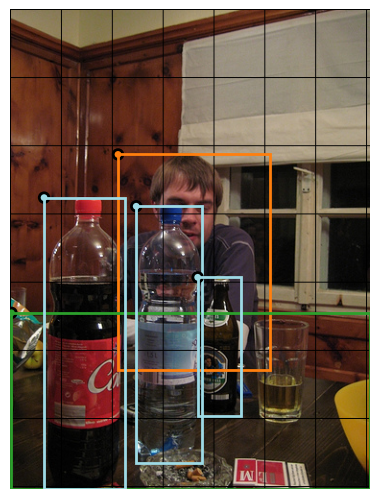

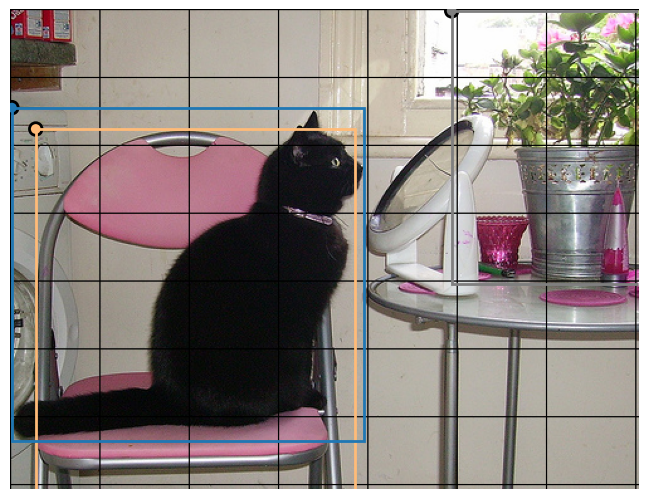

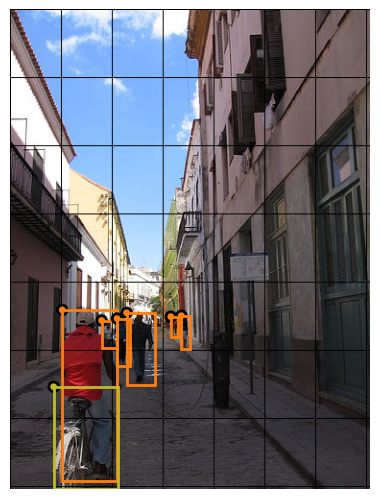

In [97]:
cmap = plt.get_cmap('tab20')

colors = dict([(category, cmap(i / num_classes)) for i, category in enumerate(reversed_categories)])
keys = list(annotations["bboxes"].keys())
keys = ["2008_003781", "2009_002579", "2008_003726", "2008_001791"]
for key in keys:
    fig, ax = plt.subplots(1, 1)

    image = np.array(Image.open(os.path.join(dataset_path, f"{key}.jpg"), "r"))
    H, W, _ = image.shape

    dw, dh = int(image.shape[0] / 7), int(image.shape[1] / 7)
    grid_color = [0,0,0]

    image[:,::dh,:] = grid_color
    image[::dw,:,:] = grid_color
    ax.imshow(image)
    ax.axis("off")

    for bbox in annotations["bboxes"][f"{key}"]:
        label = bbox[0]
        bbox = bbox[1:]
        circle = patches.Circle((bbox[0], bbox[1]), radius=5, linewidth=2, edgecolor="black", facecolor=colors[label])
        ax.add_patch(circle)
        rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1], linewidth=2, edgecolor=colors[label], facecolor='none', alpha=1)
        ax.add_patch(rect)

    fig.tight_layout(pad=0, h_pad=0, w_pad=0)
    plt.savefig(os.path.join(os.path.dirname(""), "plots", f"{key}"), bbox_inches='tight')
plt.show()

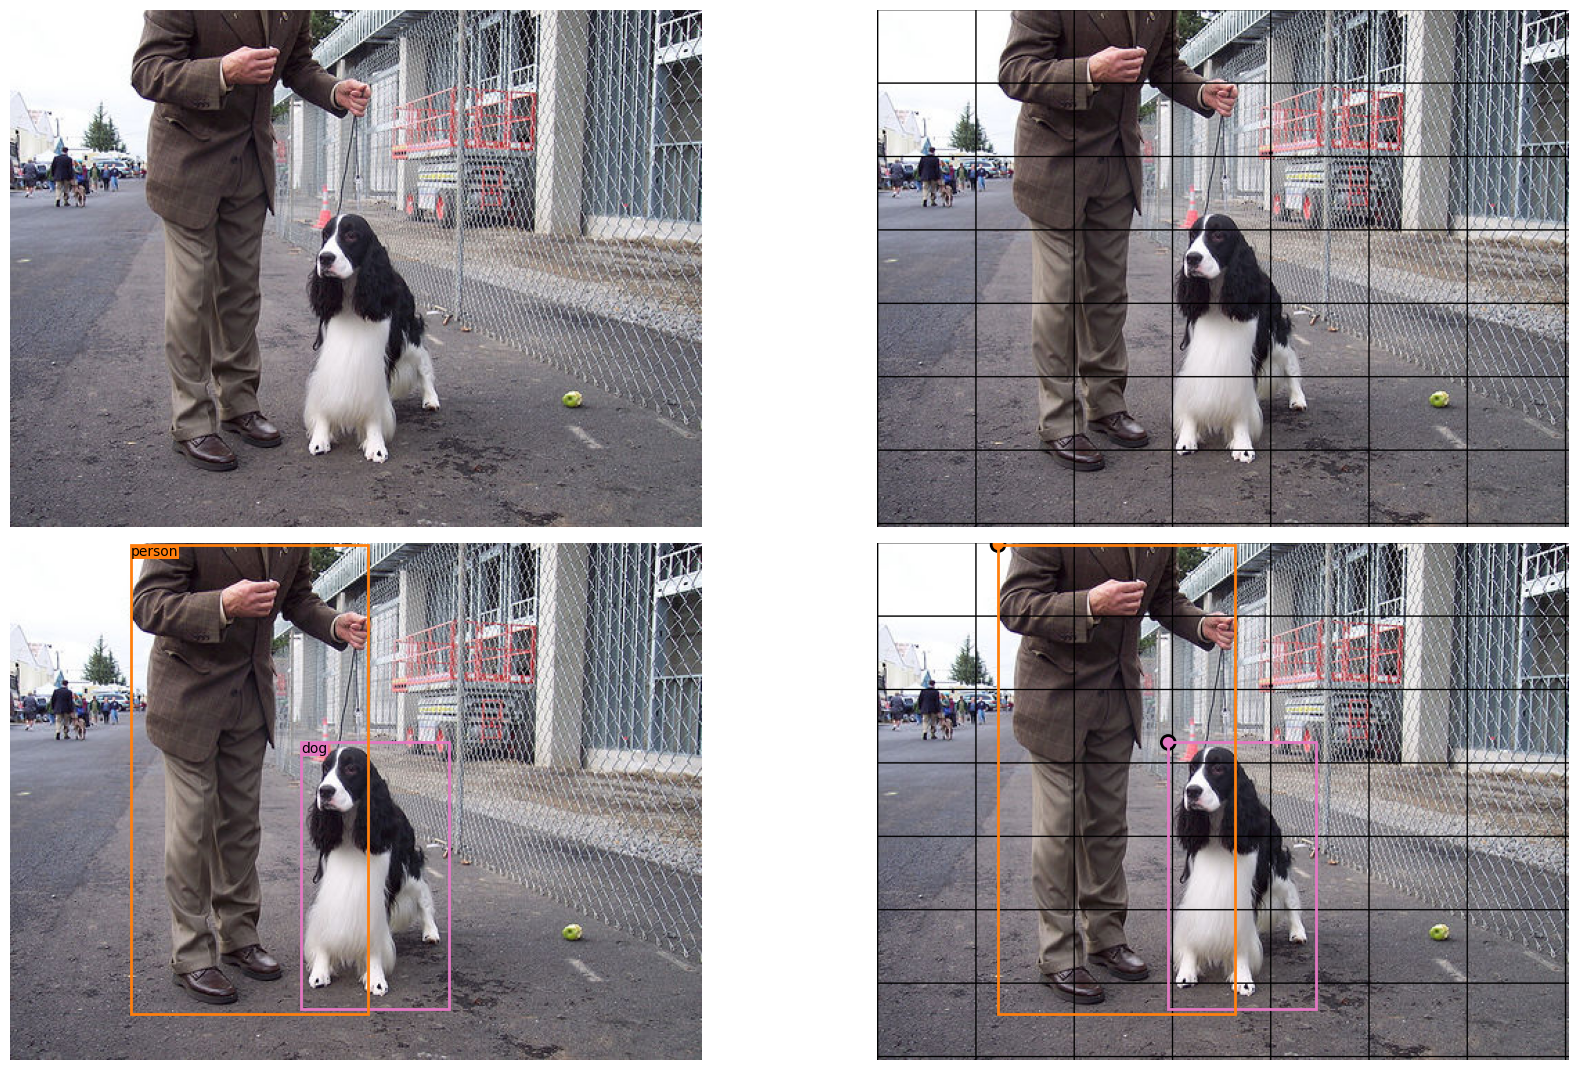

In [22]:
cmap = plt.get_cmap('tab20')

colors = dict([(category, cmap(i / num_classes)) for i, category in enumerate(reversed_categories)])

fig, ax = plt.subplots(2, 2, figsize=(19.2, 10.8))

image = np.array(Image.open(os.path.join(dataset_path, "2008_001182.jpg"), "r"))
H, W, _ = image.shape

dw, dh = int(image.shape[0] / 7), int(image.shape[1] / 7)
grid_color = [0,0,0]

img = image.copy()
for (row, col) in [(0, 1), (1, 1)]:
    img[:,::dh,:] = grid_color
    img[::dw,:,:] = grid_color
    ax[row][col].imshow(img)

for i in range(2):
    for j in range(2):
        if (i == 0 and j == 1) or (i == 1 and j == 1):
            ax[i][j].axis("off")
            continue
        ax[i][j].imshow(image)
        ax[i][j].axis("off")

for (row, col) in [(1, 0), (1, 1)]:
    for bbox in annotations["bboxes"]["2008_001182"]:
        label = bbox[0]
        bbox = bbox[1:]
        if (row, col) == (1, 1):
            circle = patches.Circle((bbox[0], bbox[1]), radius=5, linewidth=2, edgecolor="black", facecolor=colors[label])
            ax[row][col].add_patch(circle)
        rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1], linewidth=2, edgecolor=colors[label], facecolor='none', alpha=1)
        ax[row][col].add_patch(rect)

for bbox in annotations["bboxes"]["2008_001182"]:
    label = bbox[0]
    bbox = bbox[1:]
    rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1], linewidth=2, edgecolor=colors[label], facecolor='none', alpha=1)
    ax[1][0].text(bbox[0], bbox[1], reversed_categories[label], ha='left', va='top', bbox=dict(facecolor=colors[label], edgecolor="none", pad=0))

fig.tight_layout()
plt.savefig(os.path.join(os.path.dirname(""), "plots", f"YOLO_explanation"), bbox_inches="tight")
plt.show()